In [807]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
import keybert as kb
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.manifold import TSNE
from nltk.stem.snowball import SnowballStemmer

In [808]:
data_set = pd.read_csv('VKM_dataset.csv')

data_set.head()

,id,name,shortdescription,description,content,studycredit,location,contact_id,level,learningoutcomes,Rood,Groen,Blauw,Geel,module_tags,interests_match_score,popularity_score,estimated_difficulty,available_spots,start_date
0,159,Kennismaking met Psychologie,"Brein, gedragsbeinvloeding, ontwikkelingspsych...",In deze module leer je hoe je gedrag van jezel...,In deze module leer je hoe je gedrag van jezel...,15,Den Bosch,58,NLQF5,A. Je beantwoordt vragen in een meerkeuze kenn...,4.0,2.0,1.0,5.0,"['brein', 'gedragsbeinvloeding', 'ontwikkeling...",0.54,319,1,79,2025-12-24
1,160,Learning and working abroad,"Internationaal, persoonlijke ontwikkeling, ver...",Studenten kiezen binnen de (stam) van de oplei...,Studenten kiezen binnen de (stam) van de oplei...,15,Den Bosch,58,NLQF5,De student toont professioneel gedrag conform ...,5.0,3.0,1.0,1.0,"['internationaal', 'persoonlijke', 'ontwikkeli...",0.92,172,5,56,2025-12-20
2,161,Proactieve zorgplanning,"Proactieve zorgplanning, cocreatie, ziekenhuis",Het Jeroen Bosch ziekenhuis wil graag samen me...,Het Jeroen Bosch ziekenhuis wil graag samen me...,15,Den Bosch,59,NLQF5,De student past pro actieve zorgplanning toe b...,NaN,NaN,NaN,NaN,"['proactieve', 'zorgplanning', 'cocreatie', 'z...",0.78,217,5,55,2025-09-23
3,162,Rouw en verlies,"Rouw & verlies, palliatieve zorg & redeneren, ...",In deze module wordt stil gestaan bij rouw en ...,In deze module wordt stil gestaan bij rouw en ...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['rouw', 'verlies', 'palliatieve', 'zorg', 're...",0.69,454,1,54,2025-10-25
4,163,Acuut complexe zorg,"Acute zorg, complexiteit, ziekenhuis, revalidatie",In deze module kunnen studenten zich verdiepen...,In deze module kunnen studenten zich verdiepen...,30,Den Bosch,58,NLQF6,De student regisseert en voert (deels) zelfsta...,NaN,NaN,NaN,NaN,"['acute', 'zorg', 'complexiteit', 'ziekenhuis'...",0.40,178,5,38,2025-11-19


In [809]:
data_set_copy = data_set.copy()

In [810]:
# kijken naar specifieke 'ntb' waarden in kolommen
columns_to_check = ['shortdescription', 'description', 'content', 'level', 'learningoutcomes']

for col in columns_to_check:
    count = (data_set_copy[col].str.lower() == 'ntb').sum()
    print(f"{col}: {count} keer 'ntb'")

na_count = data_set_copy['studycredit'].isna().sum()
print(f"studycredit: {na_count} missing values")

tags_count = (data_set_copy['module_tags'].str.lower() == "['ntb']").sum()
print(f"module_tags: {tags_count} keer ['ntb']")


shortdescription: 10 keer 'ntb'
description: 2 keer 'ntb'
content: 2 keer 'ntb'
level: 0 keer 'ntb'
learningoutcomes: 26 keer 'ntb'
studycredit: 0 missing values
module_tags: 10 keer ['ntb']


# Data-opschonen

In [811]:
columns_to_drop = ['Rood', 'Geel', 'Groen', 'Blauw']
if all(col in data_set_copy.columns for col in columns_to_drop):
    data_set_copy.drop(columns=columns_to_drop, inplace=True)

# Vervangen van 'ntb', 'Ntb' en "['ntb']" met NaN waardes, zodat deze als missende waardes worden herkend en consistent zijn door de dataset heen.
# Vervangen van waarden die niet compleet zijn met NaN waardes, zodat deze als missende waardes worden herkend en consistent zijn door de dataset heen.
values_to_replace = ['ntb', 'Ntb', "['ntb']", 'Nog niet bekend', 'nog niet bekend', 
                     "Nader te bepalen", "n.n.b.", "Nog nader te bepalen", "Nog te formuleren"]
for value in values_to_replace:
    data_set_copy.replace(value, np.nan, inplace=True)

# start_date naar datetime (foute waarden → NaT)
data_set_copy['start_date'] = pd.to_datetime(data_set_copy['start_date'], errors='coerce')

# Missende tekst invullen met eerste zin uit een andere kolom
fill_map = {
    'shortdescription': 'description',
    'description': 'shortdescription',
    'content': 'description'
}
for target, source in fill_map.items():
    data_set_copy[target] = data_set_copy[target].fillna(data_set_copy[source].str.split('.').str[0])

# Alle tekstkolommen: lowercase + trimmen
text_columns = ['shortdescription', 'description', 'content', 'learningoutcomes', 'name']
data_set_copy[text_columns] = data_set_copy[text_columns].apply(lambda col: col.str.lower().str.strip()) 


#fill missing module_tags
kw_model = kb.KeyBERT()
moduleTags = []
#datafilteren
datacopy = data_set_copy.copy()

#alle nan values module_tags krijgen
nan_module_tags = data_set_copy[data_set_copy['module_tags'].isna()]

custom_stopwords = ['de', 'het', 'een', 'en', 'van', 'op', 'in', 'met', 'voor', 'door']

# loopen door de dataset en de description eruit halen en daarna keybert gebruiken om tags te maken die toegevoegd wordt aan module_tags
for index, row in nan_module_tags.iterrows():
    text = row['description']
    keywords = kw_model.extract_keywords(text, stop_words=custom_stopwords, keyphrase_ngram_range=(1,1), top_n=3)
    tags = [kw[0] for kw in keywords]
    moduleTags.append(tags)


nan_module_tags.loc[nan_module_tags['module_tags'].isna(), 'module_tags'] = np.array(moduleTags, dtype=object)
data_set_copy['module_tags'] = data_set_copy['module_tags'].fillna(
    nan_module_tags['module_tags'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)
)

# Er zijn waarden in de kolom 'module_tags' die speciale karakters bevatten zoals [ ]'. Deze heb ik verwijderd zodat de tags beter leesbaar zijn en consistent zijn.
data_set_copy['module_tags'] = data_set_copy['module_tags'].str.replace(r"[\[\]']", '', regex=True)

# dubbele rijen verwijderen uit de dataset als deze er zijn om de analyse niet te verstoren.
data_set_copy.drop_duplicates(inplace=True)

# index resetten na het verwijderen van dubbele rijen
data_set_copy.reset_index(drop=True, inplace=True)

# Nieuwe kolom 'status' toevoegen die aangeeft of de module definitief is of voorlopig op basis van missende waardes.
data_set_copy['status'] = np.where(data_set_copy.isna().any(axis=1), 'voorlopig', 'definitief')

#data_set_copy.to_csv('VKM_dataset_cleaned.csv', index=False)

# Visualisatie & Trendanalyse 

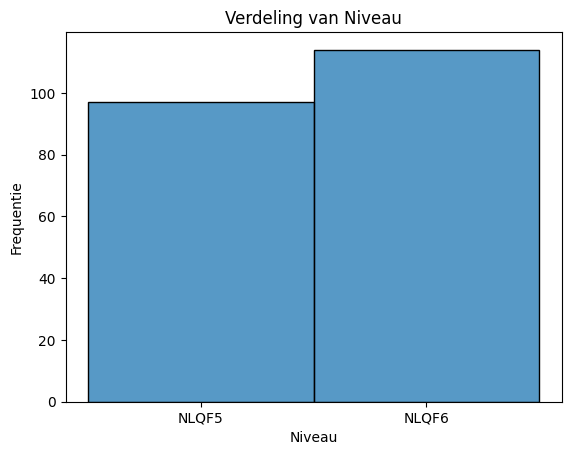

In [812]:
sns.histplot(data_set_copy['level'].dropna())
plt.title('Verdeling van Niveau')
plt.xlabel('Niveau')
plt.ylabel('Frequentie')
plt.show()

<Axes: xlabel='level', ylabel='interests_match_score'>

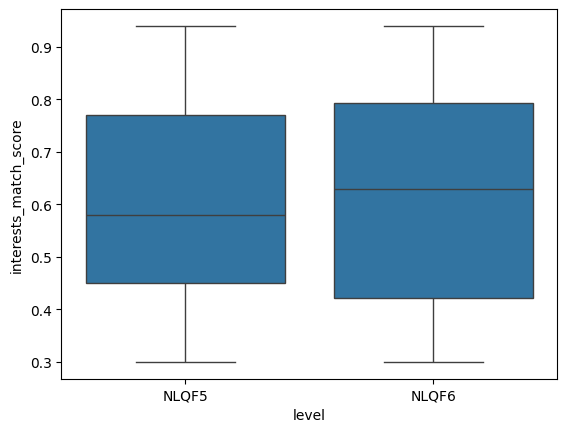

In [813]:
sns.boxplot(x='level', y='interests_match_score', data=data_set_copy)

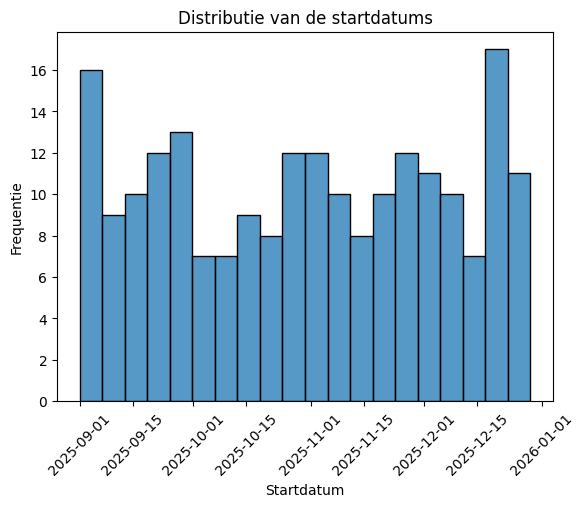

In [814]:
sns.histplot(data_set_copy['start_date'].dropna(), bins=20)
plt.title('Distributie van de startdatums')
plt.xticks(rotation=45)
plt.xlabel('Startdatum')
plt.ylabel('Frequentie')
plt.show()

# Hier kijk ik naar de distributie van de startdatums in de dataset.
# Dit kan helpen om te begrijpen of er bepaalde periodes zijn waarin meer modules starten.

<Axes: xlabel='status', ylabel='Count'>

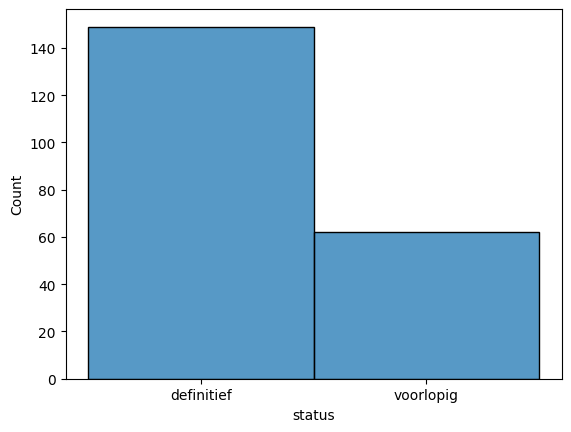

In [815]:
sns.histplot(data_set_copy['status'].dropna(), bins=20)

<Axes: xlabel='level', ylabel='estimated_difficulty'>

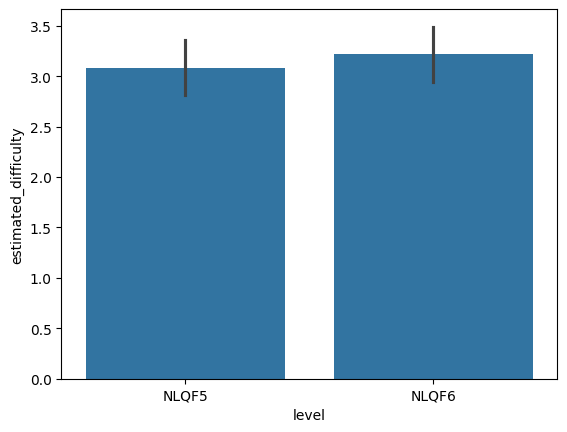

In [816]:
sns.barplot(x='level', y='estimated_difficulty', data=data_set_copy)

<Axes: >

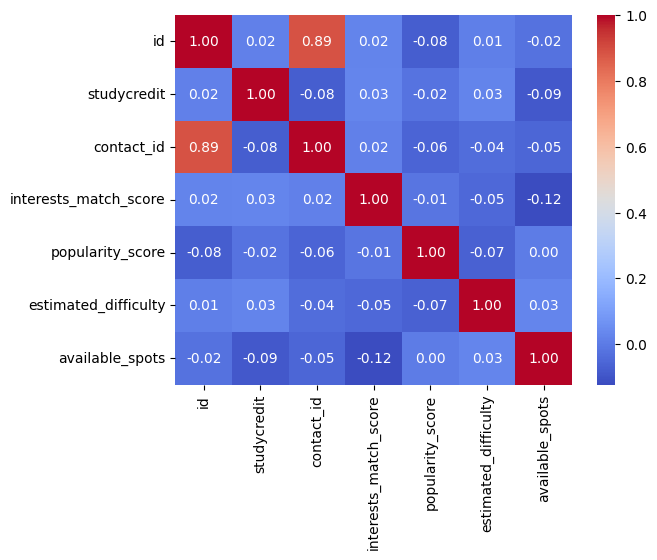

In [817]:
sns.heatmap(data_set_copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

description         99
shortdescription    73
content             99
dtype: int64


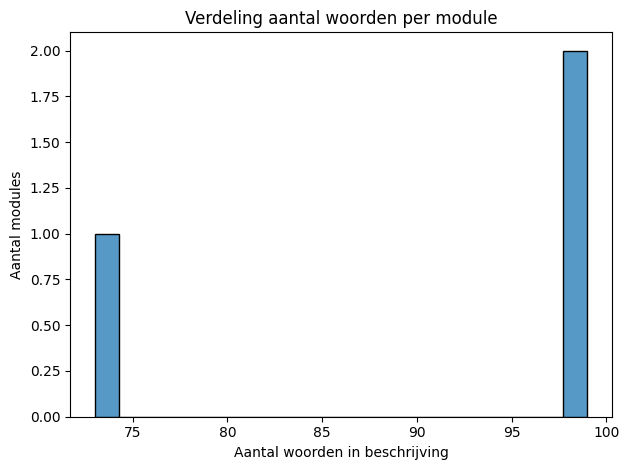

In [818]:
text_col =  ['description', 'shortdescription', 'content']
data_set_copy[text_col] = data_set_copy[text_col].fillna("")
word_counts = data_set_copy[text_col].apply(lambda x: len(str(x).split()))

print(word_counts)
# Histogram
plt.figure()
sns.histplot(word_counts, bins=20)
plt.title("Verdeling aantal woorden per module")
plt.xlabel("Aantal woorden in beschrijving")
plt.ylabel("Aantal modules")
plt.tight_layout()
plt.show()

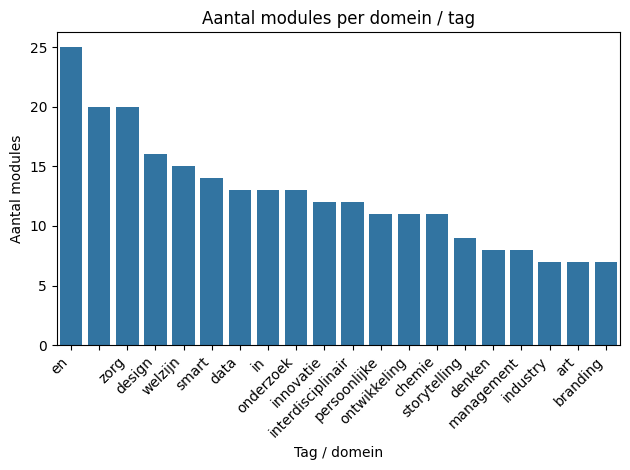

In [819]:
data_set_copy['module_tags'] = data_set_copy['module_tags'].fillna('')
df_tags = data_set_copy['module_tags'].str.split(',', expand=True).stack().str.strip()
df_tags.name = 'tag'

top_n = 20
tag_counts = df_tags.value_counts()

tag_counts_top = tag_counts.head(top_n)

plt.figure()
sns.barplot(x=tag_counts_top.index, y=tag_counts_top.values)
plt.title("Aantal modules per domein / tag")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Tag / domein")
plt.ylabel("Aantal modules")
plt.tight_layout()
plt.show()

# Hybrid-Recommender model

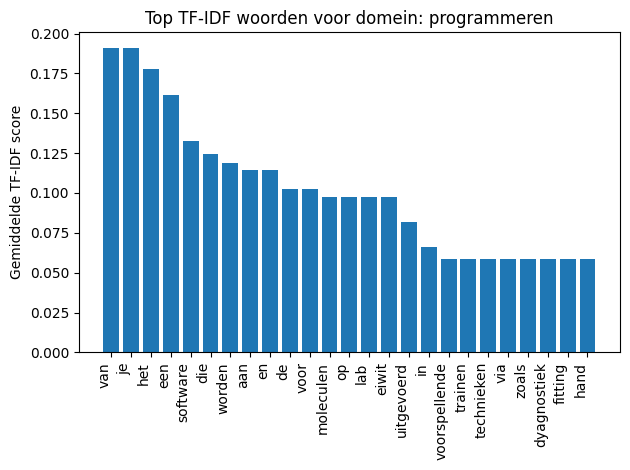

In [820]:
text_col =  'description'
data_set_copy[text_col] = data_set_copy[text_col].fillna("")
data_set_copy['module_tags'] = data_set_copy['module_tags'].fillna("")

domein = "programmeren"

mask = data_set_copy['module_tags'].str.contains(domein, case=False, na=False)
docs = data_set_copy.loc[mask, text_col].tolist()


vectorizer = TfidfVectorizer(max_features=100) 
X = vectorizer.fit_transform(docs)

# Gemiddelde tf-idf score per woord
mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
words = np.array(vectorizer.get_feature_names_out())

# Sorteer op score
top_idx = mean_tfidf.argsort()[::-1]
top_words = words[top_idx][:25]
top_scores = mean_tfidf[top_idx][:25]

plt.figure()
plt.bar(range(len(top_words)), top_scores)
plt.xticks(range(len(top_words)), top_words, rotation=90, ha='right')
plt.title(f"Top TF-IDF woorden voor domein: {domein}")
plt.ylabel("Gemiddelde TF-IDF score")
plt.tight_layout()
plt.show()

## Train data_set

In [881]:
test = set(stopwords.words('dutch'))
if test is not None:
    print("Stopwoorden geladen.")
else:
    print("Fout bij het laden van stopwoorden.")

class Profile:
    def __init__(self, interests: str, goals: str):
        self.interests = interests
        self.goals = goals

class HybridRecommender:
    def __init__(self, 
                 profile: Profile, 
                 ifidf_features: int = None, 
                 ifidf_range: tuple = None, 
                 cosine_sim: float = 0.75, 
                 popularity_score: float = 0.05, 
                 interests_match_score: float = 0.20,
                 tuned: bool = False):
        
        self.cosine_sim_weight = cosine_sim
        self.popularity_score_weight = popularity_score
        self.interests_match_score_weight = interests_match_score
        self.stop_words = set(stopwords.words('dutch'))
        self.vectorizer = None
        self.stemmer = SnowballStemmer("dutch")
        self.scaler = StandardScaler()
        self.profile = profile
        self.ifidf_features = ifidf_features
        self.ifidf_range = ifidf_range
        self.fitted = False
        self.tuned = tuned
        self.feature_cols = [
            'cosine_sim_norm',
            'popularity_score_norm',
            'interests_match_score_norm'
        ]
        
    def baseline_vs_tuned(self):
        
        if self.tuned == True:
            # vergelijk baseline met tuned model
            self.vectorizer = TfidfVectorizer(max_features=self.ifidf_features, ngram_range=self.ifidf_range, min_df=2, max_df=0.8)
        else:
            self.vectorizer = TfidfVectorizer()    

    def preprocess_text(self, text: str):
        text_lower = text.lower()
        text_no_numbers = re.sub(r'\d+', '', text_lower)
        text_no_punct = re.sub(r'[^\w\s]', '', text_no_numbers)
        tokens = []
        for sentence in sent_tokenize(text_no_punct):
            words = word_tokenize(sentence)
            filtered = [w for w in words if w not in self.stop_words]
            filtered = [self.stemmer.stem(w) for w in filtered]
            tokens.extend(filtered)
        return ' '.join(tokens)

    def combine_text(self, dataset):
        return (
            dataset['name'].fillna('') + ' ' +
            dataset['shortdescription'].fillna('') + ' ' +
            dataset['description'].fillna('') + ' ' +
            dataset['content'].fillna('') + ' ' +   
            dataset['learningoutcomes'].fillna('') + ' ' +
            dataset['module_tags'].fillna('')
        )
    
    def fit(self, data: pd.DataFrame):
        self.dataset = data
        self.baseline_vs_tuned()
        # Hier maak ik een gecombineerde tekstkolom voor TF-IDF
        self.dataset['combined_text'] = self.combine_text(self.dataset)
        
        # Hier preprocess ik de gecombineerde tekstkolom
        if self.tuned == True:
            preprocessed_texts = [
                self.preprocess_text(t) for t in self.dataset['combined_text']
            ]
                    
            # Hier train ik het TF-IDF model op de preprocessed teksten
            self.tfidf_matrix = self.vectorizer.fit_transform(preprocessed_texts)
            
            # Hier maak ik een tfidf_score feature
            self.dataset['tfidf_score'] = self.tfidf_matrix.sum(axis=1).A1

            # Hier normaliseer ik vaste features
            self.dataset['popularity_score_norm'] = MinMaxScaler().fit_transform(
                self.dataset['popularity_score'].values.reshape(-1, 1)
            )
            self.dataset['interests_match_score_norm'] = MinMaxScaler().fit_transform(
                self.dataset['interests_match_score'].values.reshape(-1, 1)
            )
            self.dataset['tfidf_score_norm'] = MinMaxScaler().fit_transform(
                self.dataset['tfidf_score'].values.reshape(-1, 1)
            )
        else:
            self.dataset['combined_text'] = self.combine_text(self.dataset)
            # Heel simpele preprocessing: alles lowercase
            texts = self.dataset['combined_text'].fillna('')
            texts = texts.str.lower()
            # TF-IDF trainen (baseline: geen speciale opties)
            self.tfidf_matrix = self.vectorizer.fit_transform(texts)
            
        self.fitted = True
        
    def recommend(self, top_k: int = 5):
        if not self.fitted:
            raise ValueError("Model is nog niet getraind. Roep eerst .fit(...) aan.")
        
        try:
            if np.round(self.cosine_sim_weight + self.popularity_score_weight + self.interests_match_score_weight, decimals=2) != 1.0:
                raise ValueError("De gewichten moeten optellen tot 1.0")
        except Exception as e:
            print("Fout bij het controleren van de gewichten:", e)
            return None
        
        if self.profile is None:
            raise ValueError("Profiel is niet ingesteld. Stel eerst het profiel in voordat je aanbevelingen doet.")
        
        if self.tuned == True:
            # Hier preprocess ik de studenttekst
            student_text = self.preprocess_text(self.profile.interests + ' ' + self.profile.goals)

            # Hier maak ik een vector van de studenttekst met dezelfde TF-IDF vectorizer
            student_vector = self.vectorizer.transform([student_text])

            # Hier bereken ik de cosine similarity tussen de student vector en alle module vectors
            similarities = cosine_similarity(student_vector, self.tfidf_matrix).flatten()
            self.dataset['cosine_sim'] = similarities

            # hier normaliseer ik de cosine similarity scores
            self.dataset['cosine_sim_norm'] = MinMaxScaler().fit_transform(
                self.dataset['cosine_sim'].values.reshape(-1, 1)
            )

            # Dit is de baseline voor hybrid score (handmatig gewogen)
            self.dataset['hybrid_score_handmade'] = (
                self.cosine_sim_weight * self.dataset['cosine_sim_norm'] +
                self.popularity_score_weight * self.dataset['popularity_score_norm'] +
                self.interests_match_score_weight * self.dataset['interests_match_score_norm']
            )
            self.dataset['hybrid_score'] = self.dataset['hybrid_score_handmade']
            
            return self.dataset.sort_values(by=['hybrid_score_handmade'], ascending=False).head(top_k)
        else:
            # Student-profiel samenvoegen
            student_text = (self.profile.interests.lower() + ' ' + self.profile.goals.lower())

            # Student vector
            student_vector = self.vectorizer.transform([student_text])

            # Cosine similarity tussen student en alle modules
            similarities = cosine_similarity(student_vector, self.tfidf_matrix).flatten()
            self.dataset['cosine_sim'] = similarities

            # Aanbevelingen puur op cosine_sim
            top_modules = self.dataset.sort_values('cosine_sim', ascending=False).head(top_k)

            return top_modules  
    
    def explain_recommendation(self, profile: Profile, module_row):
        
        explanation = {}
        
        if self.tuned == True:
            
            w_cos = self.cosine_sim_weight
            w_pop = self.popularity_score_weight
            w_int = self.interests_match_score_weight
            
            explanation['gewichten'] = {
                'cosine_sim_weight': w_cos,
                'popularity_score_weight': w_pop,
                'interests_match_score_weight': w_int
            }
            
            explanation['feature_scores'] = {
                'cosine_sim_norm': float(module_row['cosine_sim_norm']),
                'popularity_score_norm': float(module_row['popularity_score_norm']),
                'interests_match_score_norm': float(module_row['interests_match_score_norm']),
                'hybrid_score': float(module_row['hybrid_score'])
            }
            
            feature_names = self.vectorizer.get_feature_names_out()
            module_index = module_row.name
            
            module_vector = self.tfidf_matrix[module_index].toarray()[0]
            top_indices = module_vector.argsort()[-5:][::-1]
            top_words = [feature_names[i] for i in top_indices]
            
            explanation['top_tfidf_words'] = top_words
            
            student_text_cleaned = self.preprocess_text(profile.interests + ' ' + profile.goals)
            student_words = set(student_text_cleaned.split())
            module_words = set(module_row['combined_text'].split())
            
            common_words = list(student_words.intersection(module_words))
            explanation['common_words'] = common_words[:10]
            
            explanation['summary'] = (
                f"Deze module scoort hoog omdat er {len(common_words)} woorden overeenkomen met jouw input. "
                f"en in de input van de student {common_words[:5]} voorkomen. "
                f"en omdat belangrijke inhoudelijke termen zoals {top_words[:3]} sterk voorkomen. "
                f"en populariteit ({module_row['popularity_score_norm']:.2f}) bij aan de totaalscore. "
                f"en interesses match ({module_row['interests_match_score_norm']:.2f}) bij aan de totaalscore. "
            )
        else:
            feature_names = self.vectorizer.get_feature_names_out()
            module_index = module_row.name

            module_vector = self.tfidf_matrix[module_index].toarray()[0]
            top_indices = module_vector.argsort()[-5:][::-1]
            top_words = [feature_names[i] for i in top_indices]

            student_text_cleaned = self.preprocess_text(profile.interests + ' ' + profile.goals)
            
            student_words = set(student_text_cleaned.split())
            module_words = set(module_row['combined_text'].split())

            common_words = list(student_words.intersection(module_words))

            explanation['top_tfidf_words'] = top_words
            explanation['common_words'] = common_words[:10]

            explanation['summary'] = (
                f"Deze module is aanbevolen door de baseline omdat de TF-IDF cosine similarity "
                f"hoog is. Er zijn {len(common_words)} gezamenlijke woorden "
                f"(bijvoorbeeld {common_words[:5]}), en belangrijke termen zoals {top_words[:3]} "
                f"komen sterk naar voren in de modulebeschrijving."
            )

        return explanation
       
    def show_plot(self, plot_type: str, title: str, xlabel: str, ylabel: str):
        
        tfidf = self.tfidf_matrix.toarray()
        tfidf = self.scaler.fit_transform(tfidf)
        model = None
        X_type = None
        if plot_type == 'PCA':
            model = PCA(n_components=2)
            X_type = model.fit_transform(tfidf)
        elif plot_type == 'UMAP':
            model = UMAP(n_components=2, random_state=42)
            X_type = model.fit_transform(tfidf)
        elif plot_type == 'TSNE':
            model = TSNE(n_components=2, random_state=42)
            X_type = model.fit_transform(tfidf)
        else:
            raise ValueError("Ongeldig plot_type. Kies uit 'PCA', 'UMAP', of 'TSNE'.")
        
        if X_type is not None:
            plt.figure(figsize=(6, 3))
            plt.scatter(X_type[:, 0], X_type[:, 1], alpha=0.7)
            plt.title(title)
            plt.xlabel(xlabel)
            plt.ylabel(ylabel)
            plt.show()
            return

Stopwoorden geladen.


### Baseline

In [822]:
popularity_score = 'popularity_score'
random = 42
 
 
def baseline_recommend(k=5):
    if popularity_score in data_set_copy.columns:
        return data_set_copy.sort_values(popularity_score, ascending=False).head(k)
    return data_set_copy.sample(k, random_state=random)
 
 
baseline_results = baseline_recommend(k=5)
print("Baseline aanbevelingen (populairste modules):")
baseline_results[['name', 'description']].head()

Baseline aanbevelingen (populairste modules):


,name,description
158,chemie & gezondheid,chemie & gezondheid (werktitel) gaat over voed...
85,module 4.1/4.2: drowning cities (bestaande minor),an interdisciplinary team of student (urban pl...
101,safety first,het organiseren van sociale en fysieke veilige...
5,kraam kind en jeugd,in deze module kunnen studenten zich verdiepen...
161,module intro to material and energy transition,module 2.3. get an introduction to doing resea...


In [823]:
def print_recommendations_with_explanations(recommender, profile, top_rec):

    for index, row in top_rec.iterrows():
        explanation = recommender.explain_recommendation(profile, row)
        print("Uitleg voor module:", row["name"]+ "\n")
        for value in explanation['summary'].split('. '):
            print(f"{value}")
        print("Belangrijkste TF-IDF woorden:", explanation["top_tfidf_words"])
        print("Gedeelde woorden:", explanation["common_words"])
        print()

# Hier heb ik de Tuned attr op False gezet

In [865]:
student_input = "ik wil programmeren, ai en data-analyse verkennen"
goals = "Ik wil mijn vaardigheden verbeteren en nieuwe technologieën leren en software ontwikkelen."
student_profile = Profile(interests=student_input, goals=goals)
recommender = HybridRecommender(student_profile, tuned=False, cosine_sim=0.75, popularity_score=0.05, interests_match_score=0.20)
recommender.fit(data_set_copy)
top_rec = recommender.recommend(top_k=5)
top_rec[['name', 'description', 'shortdescription', 'level', 'location', 'cosine_sim']].head()

,name,description,shortdescription,level,location,cosine_sim
121,verantwoord en duurzaam innoveren met nieuwe t...,het voorstel is om deze keuze module een “voor...,"ai, innovatie, verantwoord, businessmodel",NLQF6,Den Bosch,0.191748
192,creative ai,"gezamenlijk onderzoek naar creatieve, artistie...","ai, creatieve sector, makerschap, originalitei...",NLQF6,Breda en Den Bosch,0.175098
167,forensische chemie,in de forensische wetenschap is chemische anal...,"chemische analyse, data analyse, forensic scie...",NLQF6,Breda en Den Bosch,0.153209
125,systems programming in c++,in een projectgroep bouw je met behulp van c++...,"projectaanpak, programmeren, software, c++, solid",NLQF6,Den Bosch,0.150117
130,datagedreven besluitvorming met ai,in deze module leren studenten de basis van da...,"data science, ai, python, onderzoek",NLQF6,Breda,0.149516


# Hier heb ik de Tuned attr op True gezet

In [825]:
student_input = "ik wil programmeren en ai verkennen"
goals = "Ik wil mijn vaardigheden verbeteren en nieuwe technologieën leren en software ontwikkelen."
recommender = HybridRecommender(student_profile,ifidf_features=500, ifidf_range=(1,2), tuned=True, cosine_sim=0.75, popularity_score=0.05, interests_match_score=0.20)
recommender.fit(data_set_copy)
top_rec = recommender.recommend(top_k=5)
top_rec[['name', 'description', 'shortdescription', 'level', 'location', 'cosine_sim', 'hybrid_score', 'tfidf_score_norm']].head()

,name,description,shortdescription,level,location,cosine_sim,hybrid_score,tfidf_score_norm
121,verantwoord en duurzaam innoveren met nieuwe t...,het voorstel is om deze keuze module een “voor...,"ai, innovatie, verantwoord, businessmodel",NLQF6,Den Bosch,0.370678,0.906716,0.636628
125,systems programming in c++,in een projectgroep bouw je met behulp van c++...,"projectaanpak, programmeren, software, c++, solid",NLQF6,Den Bosch,0.400980,0.855051,0.444693
140,analyseren van software en infrastructuur (1.3...,in deze module leer je de software en infrastr...,in deze module leer je de software en infrastr...,NLQF5,Breda,0.308158,0.818768,0.434017
171,molecular modeling & data-driven analysis,m.b.v. software moleculen ontdekken die binden...,"moleculair modelleren, ""virtual screening"", da...",NLQF6,Breda,0.345774,0.698743,0.393591
192,creative ai,"gezamenlijk onderzoek naar creatieve, artistie...","ai, creatieve sector, makerschap, originalitei...",NLQF6,Breda en Den Bosch,0.218828,0.638369,0.589927


# Hier heb ik de Tuned attr op False gezet voor profiel 2

In [826]:
student2_input = "Ik wil in de zorg werken en mensen helpen met technologie"
student2_goals = "Ik wil mijn kennis van gezondheidszorg en technologie combineren om innovatieve oplossingen te ontwikkelen."
student2_profile = Profile(interests=student2_input, goals=student2_goals)
recommender2 = HybridRecommender(student2_profile, tuned=False, cosine_sim=0.75, popularity_score=0.05, interests_match_score=0.20)
recommender2.fit(data_set_copy)
top_rec2 = recommender2.recommend(top_k=5)
top_rec2[['name', 'description', 'shortdescription', 'level', 'location', 'cosine_sim']].head()

,name,description,shortdescription,level,location,cosine_sim
13,zorg dichtbij,met 'zorg op afstand' kan je met behulp van te...,"zorg op afstand, technologie, implementeren, z...",NLQF5,Breda,0.235533
17,technologie die ècht werkt: innovatie in zorg ...,hoe kan technologie de beloftes waarmaken en é...,"technologie, smart health, robotica, zorg, wel...",NLQF5,Breda,0.220353
187,inclusief samenwerken zonder verliezers,bij alle grote (en vaak ook kleine) vraagstukk...,"corporate antropologie, omgevingscommunicatie,...",NLQF6,Breda,0.179478
12,technologie in zorg en welzijn,een belangrijk vraagstuk voor de hedendaagse p...,"technologie, zorg, welzijn",NLQF6,Den Bosch,0.171357
49,welzijn en samenleving,wil je (samen met andere disciplines) een vers...,"preventie, welzijn, samenleving",NLQF5,Breda en Den Bosch,0.153798


# Hier heb ik de Tuned attr op True gezet voor profiel 2

In [827]:
student2_input = "Ik wil in de zorg werken en mensen helpen met technologie"
student2_goals = "Ik wil mijn kennis van gezondheidszorg en technologie combineren om innovatieve oplossingen te ontwikkelen."
student2_profile = Profile(interests=student2_input, goals=student2_goals)
recommender = HybridRecommender(student2_profile, ifidf_features=500, ifidf_range=(1,2), tuned=True, cosine_sim=0.75, popularity_score=0.05, interests_match_score=0.20)
recommender.fit(data_set_copy)
top_rec2 = recommender.recommend(top_k=5)
top_rec2[['name', 'description', 'shortdescription', 'level', 'location', 'cosine_sim', 'hybrid_score']].head()

,name,description,shortdescription,level,location,cosine_sim,hybrid_score
13,zorg dichtbij,met 'zorg op afstand' kan je met behulp van te...,"zorg op afstand, technologie, implementeren, z...",NLQF5,Breda,0.539325,0.832832
17,technologie die ècht werkt: innovatie in zorg ...,hoe kan technologie de beloftes waarmaken en é...,"technologie, smart health, robotica, zorg, wel...",NLQF5,Breda,0.374938,0.668465
12,technologie in zorg en welzijn,een belangrijk vraagstuk voor de hedendaagse p...,"technologie, zorg, welzijn",NLQF6,Den Bosch,0.314670,0.647461
14,langer thuis in de wijk,in nederland willen we mensen zo lang mogelijk...,"wijkgericht werken, eigen regie, zorg, welzijn...",NLQF5,Breda,0.289999,0.480679
137,engineering for non-engineers,wat betekent het om fysieke producten te reali...,smart industry / smart health / smart energy,NLQF5,Breda,0.211315,0.470365


In [886]:
print_recommendations_with_explanations(recommender2, student2_profile, top_rec2)

Uitleg voor module: zorg dichtbij

Deze module is aanbevolen door de baseline omdat de TF-IDF cosine similarity hoog is
Er zijn 3 gezamenlijke woorden (bijvoorbeeld ['kennis', 'technologie', 'zorg']), en belangrijke termen zoals ['zorg', 'afstand', 'technologie'] komen sterk naar voren in de modulebeschrijving.
Belangrijkste TF-IDF woorden: ['zorg', 'afstand', 'technologie', 'je', 'implementeren']
Gedeelde woorden: ['kennis', 'technologie', 'zorg']

Uitleg voor module: technologie die ècht werkt: innovatie in zorg en welzijn

Deze module is aanbevolen door de baseline omdat de TF-IDF cosine similarity hoog is
Er zijn 3 gezamenlijke woorden (bijvoorbeeld ['technologie', 'zorg', 'werk']), en belangrijke termen zoals ['zorg', 'technologie', 'welzijn'] komen sterk naar voren in de modulebeschrijving.
Belangrijkste TF-IDF woorden: ['zorg', 'technologie', 'welzijn', 'en', 'innovatie']
Gedeelde woorden: ['technologie', 'zorg', 'werk']

Uitleg voor module: technologie in zorg en welzijn

Deze 

In [885]:
print_recommendations_with_explanations(recommender, student_profile, top_rec)

Uitleg voor module: verantwoord en duurzaam innoveren met nieuwe technologieen

Deze module is aanbevolen door de baseline omdat de TF-IDF cosine similarity hoog is
Er zijn 4 gezamenlijke woorden (bijvoorbeeld ['ontwikkelen', 'nieuwe', 'leren', 'technologieën']), en belangrijke termen zoals ['ai', 'de', 'nieuwe'] komen sterk naar voren in de modulebeschrijving.
Belangrijkste TF-IDF woorden: ['ai', 'de', 'nieuwe', 'enz', 'businessmodel']
Gedeelde woorden: ['ontwikkelen', 'nieuwe', 'leren', 'technologieën']

Uitleg voor module: creative ai

Deze module is aanbevolen door de baseline omdat de TF-IDF cosine similarity hoog is
Er zijn 2 gezamenlijke woorden (bijvoorbeeld ['ontwikkelen', 'ai']), en belangrijke termen zoals ['ai', 'creatieve', 'en'] komen sterk naar voren in de modulebeschrijving.
Belangrijkste TF-IDF woorden: ['ai', 'creatieve', 'en', 'we', 'de']
Gedeelde woorden: ['ontwikkelen', 'ai']

Uitleg voor module: forensische chemie

Deze module is aanbevolen door de baseline omdat 

# Evaluatie baseline vs tuned

In [874]:
student_input = "ik wil programmeren en ai verkennen"
goals = "Ik wil mijn vaardigheden verbeteren en nieuwe technologieën leren en software ontwikkelen."
student_profile1 = Profile(interests=student_input, goals=goals)

student_input2 = "Ik wil in de zorg werken en mensen helpen met technologie"
goals2 = "Ik wil mijn kennis van gezondheidszorg en technologie combineren om innovatieve oplossingen te ontwikkelen."
student_profile2 = Profile(interests=student_input2, goals=goals2)

student_input3 = "ik wil data-analyse en machine learning verkennen"
goals3 = "Ik wil mijn analytische vaardigheden verbeteren en inzichten halen uit grote datasets."
student_profile3 = Profile(interests=student_input3, goals=goals3)

In [883]:
# Profiel 1
tuned_p1 = HybridRecommender(profile=student_profile1, tuned=True, ifidf_features=500, ifidf_range=(1, 2))
tuned_p1.fit(data_set_copy)
rec_p1 = tuned_p1.recommend(top_k=5)
modules_p1 = rec_p1['id'].head(5).tolist()  

# Profiel 2
tuned_p2 = HybridRecommender(profile=student_profile2, tuned=True, ifidf_features=500, ifidf_range=(1, 2))
tuned_p2.fit(data_set_copy)
rec_p2 = tuned_p2.recommend(top_k=5)
modules_p2 = rec_p2['id'].head(5).tolist()

# Profiel 3
tuned_p3 = HybridRecommender(profile=student_profile3, tuned=True, ifidf_features=500, ifidf_range=(1, 2))
tuned_p3.fit(data_set_copy)
rec_p3 = tuned_p3.recommend(top_k=5)
modules_p3 = rec_p3['id'].head(5).tolist()

In [860]:
def precision(recommended_ids, relevant_ids, k=5):
    recommended_at_k = recommended_ids[:k]
    hits = len(set(recommended_at_k) & set(relevant_ids))
    return hits / k

def recall(recommended_ids, relevant_ids, k=5):
    recommended_at_k = recommended_ids[:k]
    hits = len(set(recommended_at_k) & set(relevant_ids))
    if len(relevant_ids) == 0:
        return 0.0
    return hits / len(relevant_ids)

In [884]:
results = []

for i, (profile, relevant_ids) in enumerate([
    (student_profile1, modules_p1),
    (student_profile2, modules_p2),
    (student_profile3, modules_p3)
], start=1):

    # Baseline
    baseline_model = HybridRecommender(profile=profile, tuned=False)
    baseline_model.fit(data_set_copy)
    rec_baseline = baseline_model.recommend(top_k=5)
    baseline_ids = rec_baseline['id'].tolist()

    p5_baseline = precision(baseline_ids, relevant_ids, k=5)
    r5_baseline = recall(baseline_ids, relevant_ids, k=5)

    # Tuned
    tuned_model = HybridRecommender(
        profile=profile,
        tuned=True,
        ifidf_features=500,
        ifidf_range=(1, 2)
    )
    tuned_model.fit(data_set_copy)
    rec_tuned = tuned_model.recommend(top_k=5)
    tuned_ids = rec_tuned['id'].tolist()

    p5_tuned = precision(tuned_ids, relevant_ids, k=5)
    r5_tuned = recall(tuned_ids, relevant_ids, k=5)

    results.append({
        "profiel": f"profiel_{i}",
        "baseline_precision@5": p5_baseline,
        "baseline_recall@5": r5_baseline,
        "tuned_precision@5": p5_tuned,
        "tuned_recall@5": r5_tuned,
    })

eval_df = pd.DataFrame(results)
eval_df



,profiel,baseline_precision@5,baseline_recall@5,tuned_precision@5,tuned_recall@5
0,profiel_1,0.8,0.8,1.0,1.0
1,profiel_2,0.6,0.6,1.0,1.0
2,profiel_3,0.2,0.2,1.0,1.0


### Precision: 
- Hoeveel van wat de model aanbeveelt, is daadwerkelijk goed?
### Recall:
- Hoeveel van all goede opties heeft het model gevonden.

### Baseline vs tuned model

- **Baseline model**: gebruikt alleen TF-IDF op de gecombineerde module-teksten en cosine similarity tussen het studentenprofiel en de modulebeschrijvingen. Er zijn geen extra features of gewichten; de aanbevelingen worden gesorteerd op puur tekstuele overeenkomst.
- **Tuned model**: gebruikt een getunede TF-IDF (met max_features en n-grams) en combineert de tekstuele overeenkomsten met genormaliseerde `popularity_score` en `interests_match_score` in één hybride score met zelfgekozen gewichten. Hierdoor tellen zowel inhoudelijke match als populariteit en interesses mee.

### Ethiek & AI-Act

Ons aanbevelingssysteem valt in de categorie **laag-risico / limited-risk recommender**, omdat het geen gevoelige data gebruikt van de student.

**Transparantie.**  
Om transparant te zijn richting studenten hebben we een `explain_recommendation`-functie toegevoegd. Deze legt per aanbevolen module uit:
- welke features een rol hebben gespeeld (cosine similarity, populariteit, interests_match),
- welke woorden uit de module overlappen met de input van de student,
- welke TF-IDF-termen deze module typeren.  
Hierdoor kan de student beter begrijpen *waarom* een module wordt voorgesteld en blijft de autonomie bij de student.

**Bias en populariteitsbias.**  
Doordat we een `popularity_score` meenemen in de hybride score, bestaat het risico op **populariteitsbias**: populaire modules komen nog vaker bovenaan, terwijl minder bekende maar wel passende modules minder snel getoond worden. Dit kan ertoe leiden dat het aanbod verschraalt. Mogelijke aanpassingen zijn bijvoorbeeld:
- de weging van populariteit verlagen of begrenzen,
- of een aparte “ontdek nieuwe modules”-modus zonder populariteitscomponent.

**Privacy.**  
Het systeem gebruikt geen direct identificeerbare persoonsgegevens (zoals naam, studentnummer of e-mailadres). De input bestaat uit algemene interesse- en doelbeschrijvingen en module data uit de opleiding. Hierdoor blijft de privacy-impact beperkt.

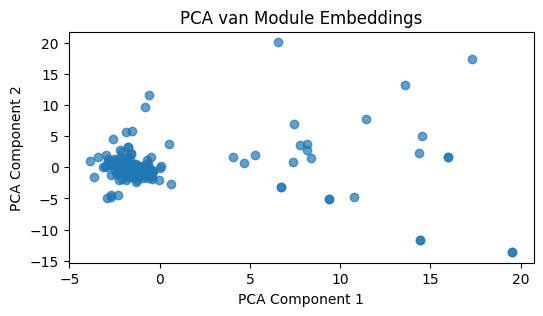

In [833]:
recommender.show_plot(plot_type='PCA', title='PCA van Module Embeddings', xlabel='PCA Component 1', ylabel='PCA Component 2')

c:\documenten\LU2-AI-Prototype\AI-PoC\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


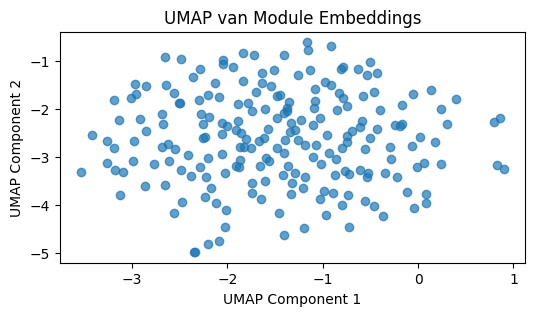

In [834]:
recommender.show_plot(plot_type='UMAP', title='UMAP van Module Embeddings', xlabel='UMAP Component 1', ylabel='UMAP Component 2')

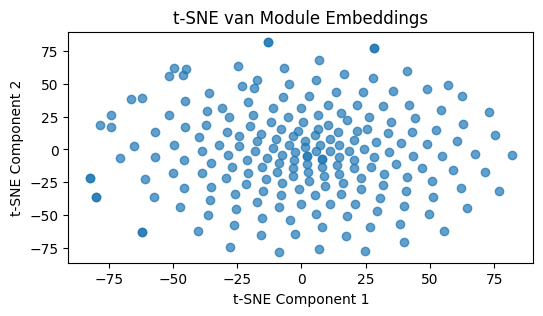

In [835]:
recommender.show_plot(plot_type='TSNE', title='t-SNE van Module Embeddings', xlabel='t-SNE Component 1', ylabel='t-SNE Component 2')

In [836]:
# import pickle
 
# with open('hybrid_recommender_model.pkl', 'wb') as f:
#     pickle.dump(recommender, f)

# model = None
# with open('hybrid_recommender_model.pkl', 'rb') as f:
#     model = pickle.load(f)
    
# top = model.recommend(student_input, top_k=5)
# top.head()